In [1]:
# notebooks/01_eda.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
df = pd.read_csv('../data/raw/application_train.csv')

# Первичный осмотр
print(f"Размер датасета: {df.shape}")
print(f"\nТипы данных:")
print(df.dtypes.value_counts())

Размер датасета: (307511, 122)

Типы данных:
float64    65
int64      41
str        16
Name: count, dtype: int64


In [2]:
# Целевая переменная
print(df['TARGET'].value_counts())
print(f"\nДоля дефолтов: {df['TARGET'].mean():.1%}")

TARGET
0    282686
1     24825
Name: count, dtype: int64

Доля дефолтов: 8.1%


In [3]:
# Анализ пропусков
missing = df.isnull().mean().sort_values(ascending=False)
missing_significant = missing[missing > 0]

print(f"Колонок с пропусками: {len(missing_significant)} из {df.shape[1]}")
print(f"Колонок с >50% пропусков: {len(missing[missing > 0.5])}")
print(f"\nТоп-15 колонок по пропускам:")
print(missing_significant.head(15).apply(lambda x: f"{x:.1%}"))

Колонок с пропусками: 67 из 122
Колонок с >50% пропусков: 41

Топ-15 колонок по пропускам:
COMMONAREA_AVG              69.9%
COMMONAREA_MODE             69.9%
COMMONAREA_MEDI             69.9%
NONLIVINGAPARTMENTS_MEDI    69.4%
NONLIVINGAPARTMENTS_MODE    69.4%
NONLIVINGAPARTMENTS_AVG     69.4%
FONDKAPREMONT_MODE          68.4%
LIVINGAPARTMENTS_AVG        68.4%
LIVINGAPARTMENTS_MEDI       68.4%
LIVINGAPARTMENTS_MODE       68.4%
FLOORSMIN_MODE              67.8%
FLOORSMIN_AVG               67.8%
FLOORSMIN_MEDI              67.8%
YEARS_BUILD_AVG             66.5%
YEARS_BUILD_MODE            66.5%
dtype: str


In [4]:
# Смотрим на числовые фичи связанные со временем
# DAYS_ колонки — количество дней до подачи заявки (отрицательные числа)
days_cols = [col for col in df.columns if 'DAYS' in col]
print(df[days_cols].describe())

          DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  \
count  307511.000000  307511.000000      307511.000000    307511.000000   
mean   -16036.995067   63815.045904       -4986.120328     -2994.202373   
std      4363.988632  141275.766519        3522.886321      1509.450419   
min    -25229.000000  -17912.000000      -24672.000000     -7197.000000   
25%    -19682.000000   -2760.000000       -7479.500000     -4299.000000   
50%    -15750.000000   -1213.000000       -4504.000000     -3254.000000   
75%    -12413.000000    -289.000000       -2010.000000     -1720.000000   
max     -7489.000000  365243.000000           0.000000         0.000000   

       DAYS_LAST_PHONE_CHANGE  
count           307510.000000  
mean              -962.858788  
std                826.808487  
min              -4292.000000  
25%              -1570.000000  
50%               -757.000000  
75%               -274.000000  
max                  0.000000  


In [5]:
# Корреляция числовых фич с целевой переменной
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('TARGET')

correlations = df[numeric_cols].corrwith(df['TARGET']).abs().sort_values(ascending=False)
print("Топ-15 фич по корреляции с TARGET:")
print(correlations.head(15).apply(lambda x: f"{x:.4f}"))

Топ-15 фич по корреляции с TARGET:
EXT_SOURCE_3                   0.1789
EXT_SOURCE_2                   0.1605
EXT_SOURCE_1                   0.1553
DAYS_BIRTH                     0.0782
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
FLAG_EMP_PHONE                 0.0460
DAYS_EMPLOYED                  0.0449
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_DOCUMENT_3                0.0443
FLOORSMAX_AVG                  0.0440
FLOORSMAX_MEDI                 0.0438
dtype: str


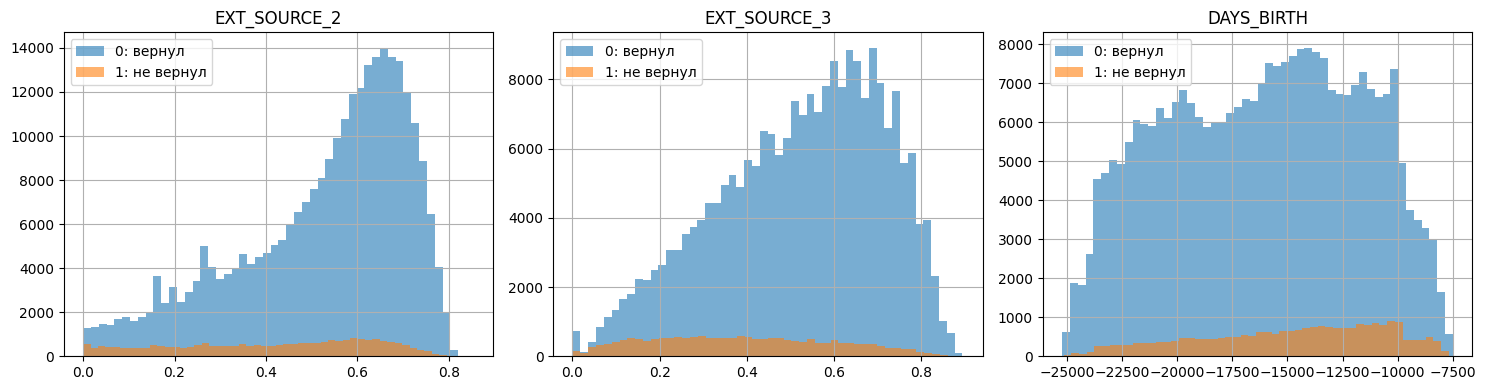

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']):
    df.groupby('TARGET')[col].hist(alpha=0.6, ax=axes[i], bins=50)
    axes[i].set_title(col)
    axes[i].legend(['0: вернул', '1: не вернул'])

plt.tight_layout()
plt.savefig('../data/processed/eda_key_features.png')
plt.show()

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Берём только топ фичи из EDA — числовые, без категориальных
features = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL',
    'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE'
]

X = df[features]
y = df['TARGET']

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc', n_jobs=-1)

print(f"ROC-AUC по фолдам: {np.round(scores, 4)}")
print(f"Mean ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

ROC-AUC по фолдам: [0.7249 0.7255 0.7212 0.7272 0.7303]
Mean ROC-AUC: 0.7258 ± 0.0030
